# Time Series Analysis, Monte Carlo Simulation, and European Option Valuation: Evidence from Apple (AAPL) Stock

## 1. Introduction and Objectives

This project investigates the time-series properties of Apple Inc. (AAPL) stock prices and returns using daily historical market data from January 2016 to December 2025. As one of the most actively traded and liquid equities in global financial markets, AAPL provides a suitable case study for applying statistical and computational finance techniques.

The primary objective is to analyze the characteristics of the underlying asset's time series and assess its suitability for financial modeling, simulation, and derivative valuation. The analysis follows three main stages:

### i. Time Series Analysis

The first stage focuses on understanding the statistical properties of AAPL prices and returns. Specifically, the analysis aims to:

* Retrieve and preprocess historical daily price data.
* Calculate simple and logarithmic returns.
* Examine descriptive statistics and distributional properties.
* Assess stationarity using the Augmented Dickey-Fuller (ADF) test.
* Investigate autocorrelation patterns through ACF and PACF analysis.
* Identify and evaluate suitable ARIMA(p,d,q) models.
* Analyze volatility and risk-return characteristics.

### ii. Monte Carlo Simulation

The second stage uses the historical return characteristics to estimate model parameters and generate simulated future price paths. The objectives are to:

* Estimate drift and volatility parameters from historical returns.
* Model stock-price dynamics using Geometric Brownian Motion (GBM).
* Generate a large number of potential future price scenarios.
* Evaluate whether the simulated paths reproduce the observed risk-return profile of the asset.

### iii. European Option Valuation

The final stage applies Monte Carlo simulation techniques to price derivatives written on the underlying asset. The objectives are to:

* Value European call and put options on AAPL stock.
* Estimate expected discounted payoffs under risk-neutral assumptions.
* Compare Monte Carlo estimates with Black-Scholes benchmark prices.
* Assess the accuracy and consistency of the simulation framework.

By combining time-series analysis, stochastic simulation, and option-pricing methods, this project demonstrates how quantitative finance techniques can be applied to analyze financial assets and value derivative securities.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy import stats

from scipy.stats import skew, kurtosis, jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## Project Settings

The selected underlying asset is Apple Inc. stock, traded under the ticker symbol AAPL. The data for Apple Inc. (AAPL) starts on January 4th, 2016, because January 1st through January 3rd fell on a weekend, making January 4th the first official trading day of the year on the Nasdaq. 

To capture exactly ten full calendar years up to 2025-12-31, the dataset spans from this initial trading day. The sample period covers ten full calendar years from 2016-01-01 to 2025-12-31. 
In the Python code, the end date is set to 2026-01-01 because the `end` argument in yfinance is treated as an exclusive boundary.

In [2]:
ticker = "AAPL"

start_date = "2016-01-01"
end_date = "2026-01-01"

trading_days = 252

print("Ticker:", ticker)
print("Report period: 2016-01-01 to 2025-12-31")
print("Python download period:", start_date, "to", end_date)

Ticker: AAPL
Report period: 2016-01-01 to 2025-12-31
Python download period: 2016-01-01 to 2026-01-01


In [3]:
# Output Folder Structure : helps to organize the outputs of the analysis, including data, figures, and tables.

data_dir = Path("data")
output_dir = Path("outputs")
fig_dir = output_dir / "figures"
table_dir = output_dir / "tables"

data_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

print("Folders are ready:")
print("Data folder:", data_dir)
print("Figures folder:", fig_dir)
print("Tables folder:", table_dir)

Folders are ready:
Data folder: data
Figures folder: outputs\figures
Tables folder: outputs\tables


## 2. Data Acquisition

Daily historical data for Apple Inc. (AAPL) are retrieved from Yahoo Finance using the Python package `yfinance`. The dataset covers ten full calendar years from 2016-01-01 to 2025-12-31. The downloaded variables include Open, High, Low, Close, Adjusted Close, and Volume.

The adjusted closing price is used as the main price variable because it accounts for corporate actions such as dividends and stock splits.

In [4]:
raw = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False,
    actions=False,
    progress=False
)

if raw.empty:
    raise ValueError("No data was downloaded. Please check the ticker symbol or internet connection.")

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

print("Shape of raw data:", raw.shape)
print("First available date:", raw.index.min())
print("Last available date:", raw.index.max())

display(raw.head())
display(raw.tail())

Shape of raw data: (2514, 6)
First available date: 2016-01-04 00:00:00
Last available date: 2025-12-31 00:00:00


Price,Adj Close,Close,High,Low,Open,Volume
2016-01-04,23.709110,26.337500,26.342501,25.500000,25.652500,270597600
2016-01-05,23.114971,25.677500,26.462500,25.602501,26.437500,223164000
2016-01-06,22.662617,25.174999,25.592501,24.967501,25.139999,273829600
2016-01-07,21.706150,24.112499,25.032499,24.107500,24.670000,324377600
2016-01-08,21.820921,24.240000,24.777500,24.190001,24.637501,283192000


Price,Adj Close,Close,High,Low,Open,Volume
2025-12-24,273.302216,273.809998,275.429993,272.200012,272.339996,17910600
2025-12-26,272.893005,273.399994,275.369995,272.859985,274.160004,21521800
2025-12-29,273.252350,273.760010,274.359985,272.350006,272.690002,23715200
2025-12-30,272.573547,273.079987,274.079987,272.279999,272.809998,22139600
2025-12-31,271.355835,271.859985,273.679993,271.750000,273.059998,27293600


In [5]:
#Saving Raw Data: it helps to preserve the original dataset for future reference or analysis, 
# ensuring that the raw data is not lost or altered during processing.
raw.to_csv(data_dir / "aapl_raw.csv", encoding="utf-8-sig")

print("Raw AAPL data saved as data/aapl_raw.csv")

Raw AAPL data saved as data/aapl_raw.csv


## 3. Data Cleaning and Preparation

Before calculating returns, the raw dataset is inspected. This includes checking the column names, data types, missing values, and date range.

In [6]:
print("Columns in raw dataset:")
print(raw.columns)

print("\nData types:")
print(raw.dtypes)

print("\nMissing values per column:")
print(raw.isna().sum())

print("\nDate range:")
print("Start:", raw.index.min())
print("End:", raw.index.max())

Columns in raw dataset:
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

Data types:
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

Missing values per column:
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Date range:
Start: 2016-01-04 00:00:00
End: 2025-12-31 00:00:00


In [7]:
# Price Selection: The adjusted closing price is selected as the main price series. 
#It is preferred over the raw closing price because it adjusts for dividends and stock splits. 
#This is especially important for long-term stock analysis.
price_col = "Adj Close" if "Adj Close" in raw.columns else "Close"

df = raw[[price_col]].copy()
df = df.rename(columns={price_col: "Price"})

df.index = pd.to_datetime(df.index)
df = df.sort_index()

print("Selected price column:", price_col)
display(df.head())
display(df.tail())

Selected price column: Adj Close


Price,Price
2016-01-04,23.709110
2016-01-05,23.114971
2016-01-06,22.662617
2016-01-07,21.706150
2016-01-08,21.820921


Price,Price
2025-12-24,273.302216
2025-12-26,272.893005
2025-12-29,273.252350
2025-12-30,272.573547
2025-12-31,271.355835


In [8]:
# Missing Value Handling: Missing values are removed from the selected price series. 
#For daily financial data, missing calendar days usually correspond to weekends 
# or market holidays and are not part of the trading-day dataset.
print("Missing values before cleaning:")
print(df.isna().sum())

df = df.dropna()

print("\nMissing values after cleaning:")
print(df.isna().sum())

print("\nClean price data shape:", df.shape)

Missing values before cleaning:
Price
Price    0
dtype: int64

Missing values after cleaning:
Price
Price    0
dtype: int64

Clean price data shape: (2514, 1)


### Returns

Stock returns measure the percentage change in the value of an asset over a specified period and provide a standardized way to evaluate investment performance. They are fundamental to financial time series analysis because they quantify price movements, facilitate comparison across assets, and form the basis for modeling volatility, forecasting future prices, and pricing financial derivatives.

Two commonly used measures of return are **simple returns** and **logarithmic (continuously compounded) returns**.

### Simple Return

The **simple return** measures the proportional change in the asset price between two consecutive periods and is computed as

$$
R_t=\frac{S_t-S_{t-1}}{S_{t-1}}
=\frac{S_t}{S_{t-1}}-1
$$

where:

- $R_t$ is the simple return at time $t$,
- $S_t$ is the adjusted closing price at time $t$,
- $S_{t-1}$ is the adjusted closing price at time $t-1$.

Simple returns are intuitive and directly represent the percentage gain or loss over a single period. They are commonly used for evaluating investment performance and calculating realized returns.

### Logarithmic (Log) Return

The **logarithmic return**, also known as the **continuously compounded return**, is calculated as the natural logarithm of the ratio of consecutive prices:

$$
r_t=\ln\left(\frac{S_t}{S_{t-1}}\right)
$$

where:

- $r_t$ is the log return at time $t$,
- $S_t$ is the adjusted closing price at time $t$,
- $S_{t-1}$ is the adjusted closing price at time $t-1$.

Log returns possess several desirable statistical properties. They are **additive over time**, meaning that the cumulative return over multiple periods is simply the sum of the individual log returns. They also tend to exhibit statistical properties that are more compatible with many financial models, including **ARIMA**, **Geometric Brownian Motion (GBM)**, and the **Black-Scholes option pricing model**.

Consequently, although both simple and log returns are computed in this study, the subsequent statistical analysis, parameter estimation, forecasting, and Monte Carlo option pricing are based primarily on **daily log returns**.

In [9]:
# Return Calculations
df["Simple_Return"] = df["Price"].pct_change()
df["Log_Return"] = np.log(df["Price"] / df["Price"].shift(1))

df = df.dropna()

print("Return data shape:", df.shape)
display(df.head())
display(df.tail())

Return data shape: (2513, 3)


Price,Price,Simple_Return,Log_Return
2016-01-05,23.114971,-0.025060,-0.025379
2016-01-06,22.662617,-0.019570,-0.019764
2016-01-07,21.706150,-0.042205,-0.043121
2016-01-08,21.820921,0.005287,0.005274
2016-01-11,22.174261,0.016193,0.016063


Price,Price,Simple_Return,Log_Return
2025-12-24,273.302216,0.005324,0.005310
2025-12-26,272.893005,-0.001497,-0.001498
2025-12-29,273.252350,0.001317,0.001316
2025-12-30,272.573547,-0.002484,-0.002487
2025-12-31,271.355835,-0.004467,-0.004477


### Final Clean Dataset Inspection

The cleaned dataset contains the adjusted AAPL price, daily simple returns, and daily log returns. This dataset will be used for exploratory data analysis and time series characterization.

In [10]:
print("Final dataset shape:", df.shape)
print("Start date in clean dataset:", df.index.min())
print("End date in clean dataset:", df.index.max())

print("\nMissing values:")
print(df.isna().sum())

display(df.describe())

Final dataset shape: (2513, 3)
Start date in clean dataset: 2016-01-05 00:00:00
End date in clean dataset: 2025-12-31 00:00:00

Missing values:
Price
Price            0
Simple_Return    0
Log_Return       0
dtype: int64


Price,Price,Simple_Return,Log_Return
count,2513.000000,2513.000000,2513.000000
mean,114.115639,0.001138,0.000970
std,73.206873,0.018300,0.018281
min,20.565865,-0.128647,-0.137708
25%,41.455296,-0.007080,-0.007105
50%,120.241310,0.001095,0.001094
75%,171.352707,0.010028,0.009978
max,285.659271,0.153288,0.142617


In [11]:
#Saving clean data for future analysis and easy access.
df.to_csv(data_dir / "aapl_clean.csv", encoding="utf-8-sig")

print("Clean AAPL data saved as data/aapl_clean.csv")

Clean AAPL data saved as data/aapl_clean.csv


## 4. Exploratory Data Analysis

### AAPL Price Series

The following plot shows the adjusted AAPL price over the ten-year sample period. This figure provides an initial visual impression of the long-term development of the stock price.

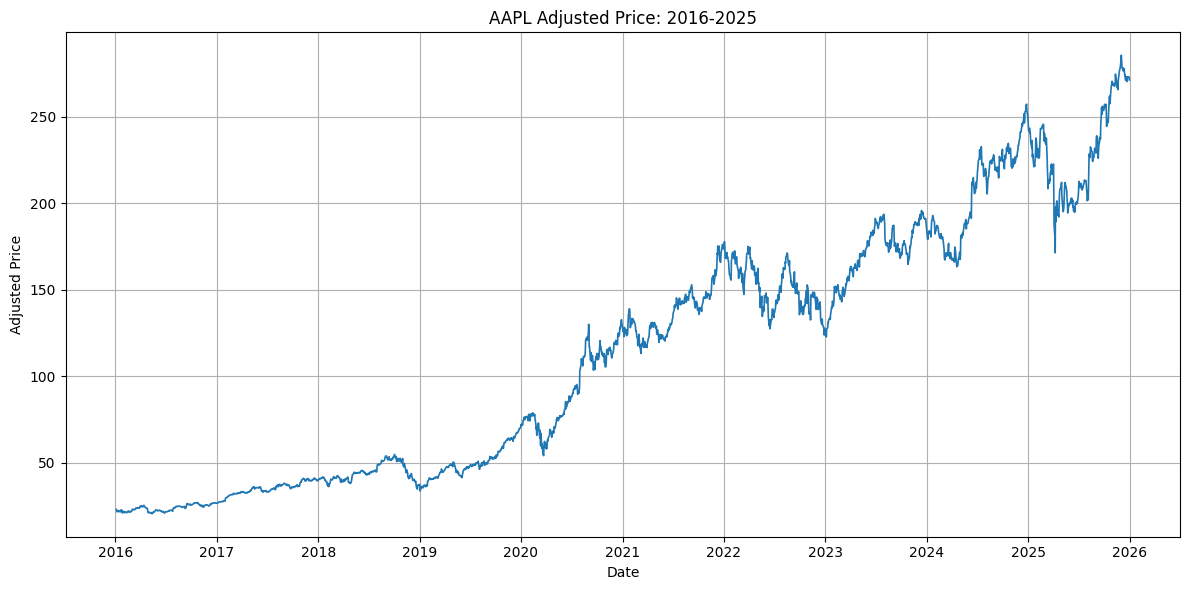

In [12]:
fig, ax = plt.subplots()

ax.plot(df.index, df["Price"], linewidth=1.2)
ax.set_title("AAPL Adjusted Price: 2016-2025")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Price")

plt.tight_layout()
plt.savefig(fig_dir / "aapl_price.png", dpi=300, bbox_inches="tight")
plt.show()

The price series shows the development of AAPL over the sample period. A visible long-term trend can be observed, which suggests that the raw price level may be non-stationary.

### AAPL Daily Log Returns

### Daily Log Returns

The **daily log return** represents the continuously compounded percentage change in the stock price from one trading day to the next. It measures the daily gain or loss of the asset while accounting for the compounding effect of returns. In this study, daily log returns are used because they are additive over time and possess statistical properties that make them suitable for financial time-series modeling.

The figure below displays the daily log returns of AAPL over the study period. Unlike the stock price series, which exhibits a long-term upward trend, the return series fluctuates around a relatively constant mean close to zero. This indicates that daily price changes are centered around an average level rather than following a persistent trend.

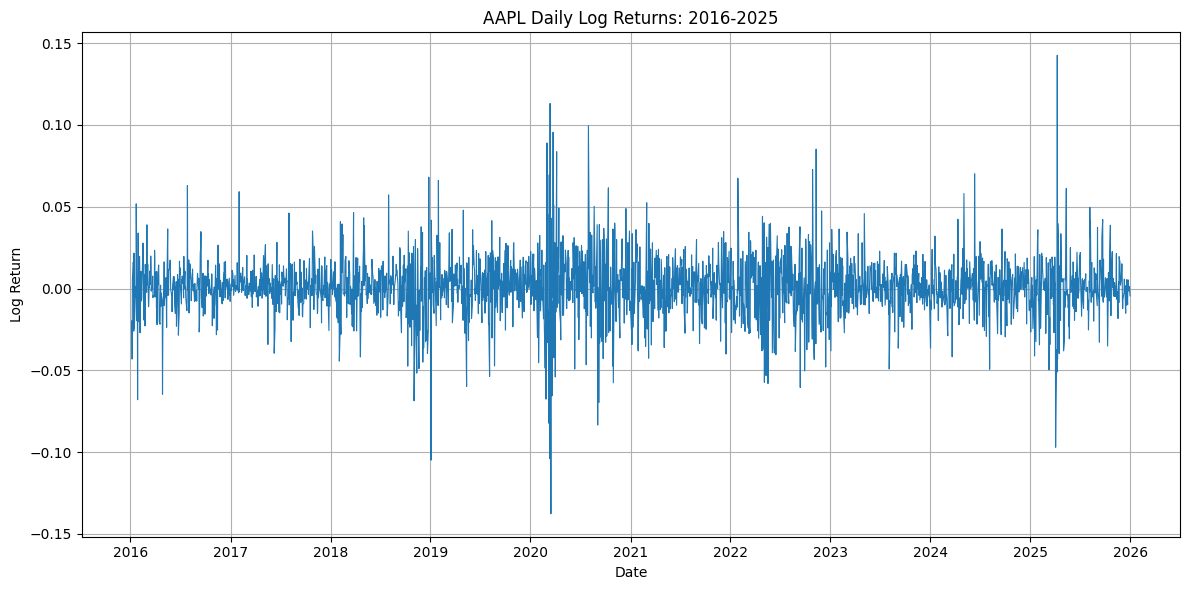

In [13]:
fig, ax = plt.subplots()

ax.plot(df.index, df["Log_Return"], linewidth=0.8)
ax.set_title("AAPL Daily Log Returns: 2016-2025")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")

plt.tight_layout()
plt.savefig(fig_dir / "aapl_log_returns.png", dpi=300, bbox_inches="tight")
plt.show()

The plot reveals periods of increased and decreased variability, a phenomenon known as **volatility clustering**, where large price movements tend to be followed by further large movements and periods of relatively small changes follow one another. These characteristics are commonly observed in financial markets and support the use of log returns for stationarity testing, ARIMA modeling, volatility estimation, and Monte Carlo simulation in the subsequent sections of this analysis.

### Distribution of AAPL Log Returns

The histogram of daily log returns is used to examine the empirical return distribution. It helps identify whether returns are approximately normally distributed or whether the data contain extreme observations and fat tails.

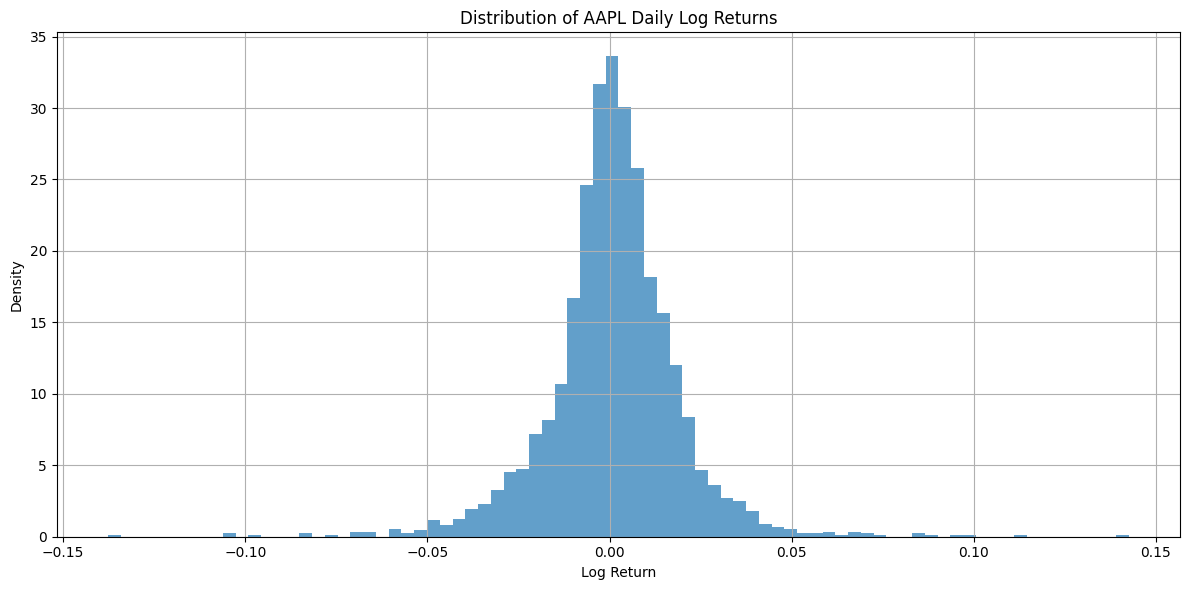

In [14]:
fig, ax = plt.subplots()

ax.hist(df["Log_Return"], bins=80, density=True, alpha=0.7)
ax.set_title("Distribution of AAPL Daily Log Returns")
ax.set_xlabel("Log Return")
ax.set_ylabel("Density")

plt.tight_layout()
plt.savefig(fig_dir / "aapl_return_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

Most daily returns are concentrated around zero. However, the distribution may contain extreme observations, suggesting that AAPL returns can deviate from a normal distribution.

### Rolling Mean of Daily Log Returns

A **rolling mean** (or moving average) is the average of a variable calculated over a fixed number of consecutive observations, with the calculation updated as the window moves through the time series. It is commonly used to smooth short-term fluctuations and reveal underlying trends or changes in the average level of the data.

In this study, the **30-trading-day rolling mean** of AAPL daily log returns is computed as

$$
\bar{r}_t=\frac{1}{30}\sum_{i=t-29}^{t}r_i,
$$

where:

- $\bar{r}_t$ is the rolling mean at time $t$,
- $r_i$ is the daily log return on day $i$,
- 30 represents the rolling window of approximately one trading month.

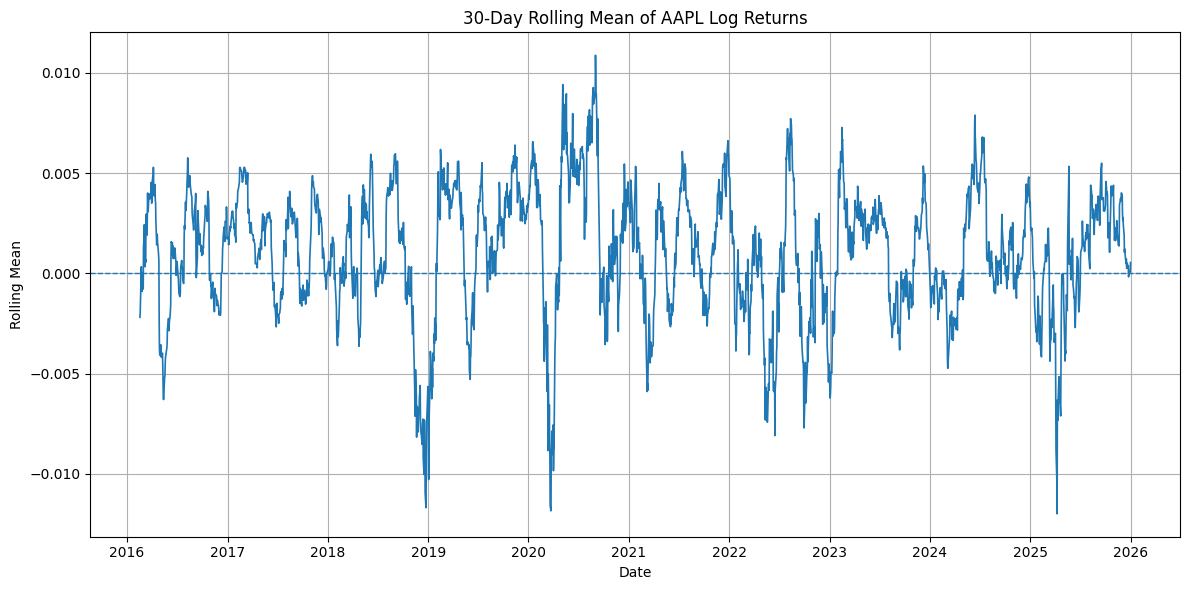

In [15]:
df["Rolling_Mean_30D"] = df["Log_Return"].rolling(window=30).mean()

fig, ax = plt.subplots()

ax.plot(df.index, df["Rolling_Mean_30D"], linewidth=1.2)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("30-Day Rolling Mean of AAPL Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Mean")

plt.tight_layout()
plt.savefig(fig_dir / "aapl_rolling_mean.png", dpi=300, bbox_inches="tight")
plt.show()

The figure above illustrates the 30-day rolling mean of AAPL daily log returns. The rolling mean remains close to zero throughout most of the sample period, indicating that the average daily return is relatively stable over time and that there is no persistent upward or downward drift in the return series. Temporary deviations from zero reflect short-term market conditions but quickly revert toward the long-run average. This behaviour supports the assumption that the return series is suitable for subsequent time-series modelling and statistical analysis.

### Rolling Volatility of Daily Log Returns

**Rolling volatility** measures how the variability of returns changes over time by computing the standard deviation of returns within a fixed moving window. Unlike the overall sample volatility, rolling volatility reveals periods of relatively high and low market risk, making it a useful tool for identifying changes in market conditions.

In this study, the **30-trading-day rolling volatility** is calculated as

$$
\sigma_t=\sqrt{\frac{1}{29}\sum_{i=t-29}^{t}(r_i-\bar{r}_t)^2},
$$

where:

- $\sigma_t$ is the rolling volatility at time $t$,
- $r_i$ is the daily log return,
- $\bar{r}_t$ is the 30-day rolling mean,
- 30 represents the rolling window.

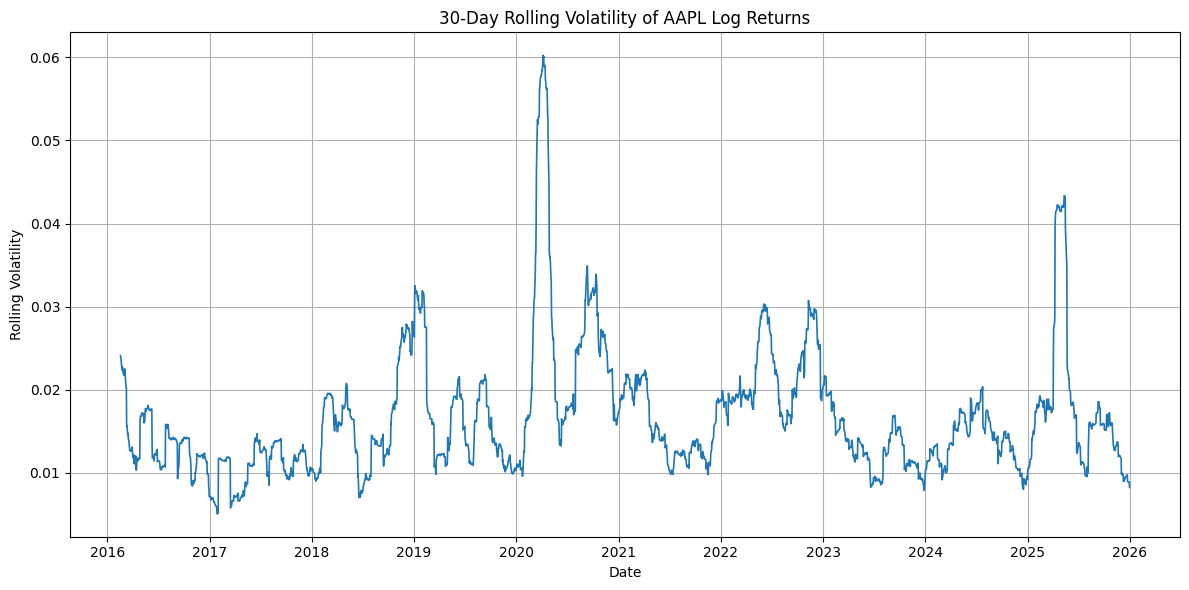

In [16]:
df["Rolling_Volatility_30D"] = df["Log_Return"].rolling(window=30).std()

fig, ax = plt.subplots()

ax.plot(df.index, df["Rolling_Volatility_30D"], linewidth=1.2)
ax.set_title("30-Day Rolling Volatility of AAPL Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Volatility")

plt.tight_layout()
plt.savefig(fig_dir / "aapl_rolling_volatility.png", dpi=300, bbox_inches="tight")
plt.show()

The figure above illustrates the 30-day rolling volatility of AAPL daily log returns. The volatility varies considerably over the sample period, indicating that market risk is not constant. Periods of elevated volatility correspond to times of increased market uncertainty, while lower volatility reflects relatively stable market conditions. This time-varying behaviour motivates the use of stochastic models for financial risk assessment and option pricing.

### Autocorrelation Function (ACF) of Daily Log Returns

The **Autocorrelation Function (ACF)** measures the correlation between a time series and its own past values at different time lags. It is commonly used to determine whether current observations are linearly related to previous observations, providing insight into the dependence structure of the series.

The sample autocorrelation at lag $k$ is defined as

$$
\rho_k=
\frac{\displaystyle\sum_{t=k+1}^{n}(r_t-\bar{r})(r_{t-k}-\bar{r})}
{\displaystyle\sum_{t=1}^{n}(r_t-\bar{r})^2},
$$

where:

- $\rho_k$ is the autocorrelation at lag $k$,
- $r_t$ is the daily log return,
- $\bar{r}$ is the sample mean return,
- $k$ denotes the lag.

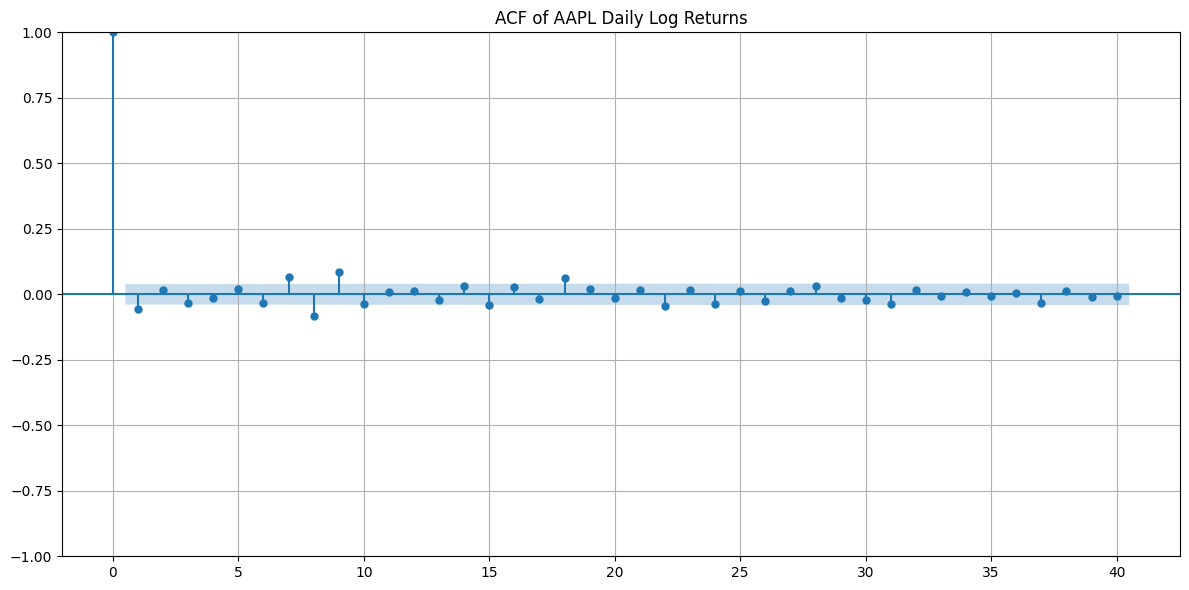

In [17]:
fig, ax = plt.subplots()

plot_acf(df["Log_Return"], lags=40, alpha=0.05, ax=ax)
ax.set_title("ACF of AAPL Daily Log Returns")

plt.tight_layout()
plt.savefig(fig_dir / "aapl_acf_returns.png", dpi=300, bbox_inches="tight")
plt.show()

The figure above presents the autocorrelation function (ACF) of AAPL daily log returns. Most of the autocorrelation coefficients lie within the 95% confidence bounds, indicating that the return series exhibits little or no statistically significant linear dependence across time. This suggests that past daily returns provide limited information for predicting future returns, which is a common characteristic of financial markets.

Although a few lags may exceed the confidence bounds, indicating weak short-term dependence, the overall pattern supports the assumption that the return series is approximately serially independent. These findings imply limited linear predictability in daily AAPL returns while providing useful information for selecting and evaluating appropriate time-series models.

## 5. Statistical and Time Series Characteristics

### Descriptive Statistics

The summary statistics provide an overview of the distributional characteristics of the return series and help assess its suitability for financial modelling. In this study, the analysis includes the **daily mean return**, **daily volatility**, **annualized mean return**, **annualized volatility**, **skewness**, **excess kurtosis**, and the **Jarque–Bera normality test**.

To examine the time-series properties of the data, the **Augmented Dickey–Fuller (ADF) test** is applied to both the AAPL price series and the daily log return series. The ADF test evaluates the null hypothesis that a time series contains a unit root (i.e., is non-stationary).

In [18]:
daily_mean = df["Log_Return"].mean()
daily_vol = df["Log_Return"].std()

annualized_mean = daily_mean * trading_days
annualized_vol = daily_vol * np.sqrt(trading_days)

jb_stat, jb_pvalue = jarque_bera(df["Log_Return"])

descriptive_stats = pd.DataFrame({
    "Metric": [
        "Number of observations",
        "Start date",
        "End date",
        "Last AAPL price",
        "Daily mean log return",
        "Daily volatility",
        "Annualized mean return",
        "Annualized volatility",
        "Minimum daily log return",
        "Maximum daily log return",
        "Skewness",
        "Excess kurtosis",
        "Jarque-Bera statistic",
        "Jarque-Bera p-value"
    ],
    "Value": [
        len(df),
        df.index.min().strftime("%Y-%m-%d"),
        df.index.max().strftime("%Y-%m-%d"),
        df["Price"].iloc[-1],
        daily_mean,
        daily_vol,
        annualized_mean,
        annualized_vol,
        df["Log_Return"].min(),
        df["Log_Return"].max(),
        skew(df["Log_Return"]),
        kurtosis(df["Log_Return"], fisher=True),
        jb_stat,
        jb_pvalue
    ]
})

display(descriptive_stats.round(6))

descriptive_stats.to_csv(table_dir / "aapl_descriptive_statistics.csv", index=False, encoding="utf-8-sig")

,Metric,Value
0,Number of observations,2513
1,Start date,2016-01-05
2,End date,2025-12-31
3,Last AAPL price,271.355835
4,Daily mean log return,0.00097
5,Daily volatility,0.018281
6,Annualized mean return,0.244436
7,Annualized volatility,0.290207
8,Minimum daily log return,-0.137708
9,Maximum daily log return,0.142617


In [19]:
def run_adf_test(series, series_name):
    result = adfuller(series.dropna(), autolag="AIC")
    
    output = {
        "Series": series_name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Lags Used": result[2],
        "Observations": result[3],
        "Critical Value 1%": result[4]["1%"],
        "Critical Value 5%": result[4]["5%"],
        "Critical Value 10%": result[4]["10%"]
    }
    
    return output

adf_price = run_adf_test(df["Price"], "AAPL Price")
adf_return = run_adf_test(df["Log_Return"], "AAPL Log Return")

adf_results = pd.DataFrame([adf_price, adf_return])

display(adf_results.round(6))

adf_results.to_csv(table_dir / "aapl_adf_results.csv", index=False, encoding="utf-8-sig")

,Series,ADF Statistic,p-value,Lags Used,Observations,Critical Value 1%,Critical Value 5%,Critical Value 10%
0,AAPL Price,0.386329,0.980976,10,2502,-3.432966,-2.862696,-2.567385
1,AAPL Log Return,-16.221226,0.000000,8,2504,-3.432964,-2.862695,-2.567385


The results indicate that the stock price series is non-stationary, whereas the daily log return series is stationary. This outcome is consistent with the characteristics of financial markets, where stock prices generally follow stochastic trends while returns fluctuate around a relatively stable mean. The stationarity of the return series justifies its use in subsequent ARIMA modelling and statistical inference.

### Volatility Clustering

**Volatility clustering** refers to the tendency of financial markets to experience periods in which large price movements are followed by further large movements, while relatively small price movements tend to be followed by additional small movements. This phenomenon is one of the most widely observed characteristics of financial return series.

The figure below plots the squared daily log returns of AAPL, which are commonly used as a proxy for volatility because large positive and negative returns both produce large squared values. Clusters of high squared returns indicate periods of elevated market uncertainty, whereas prolonged periods of low squared returns correspond to relatively stable market conditions.

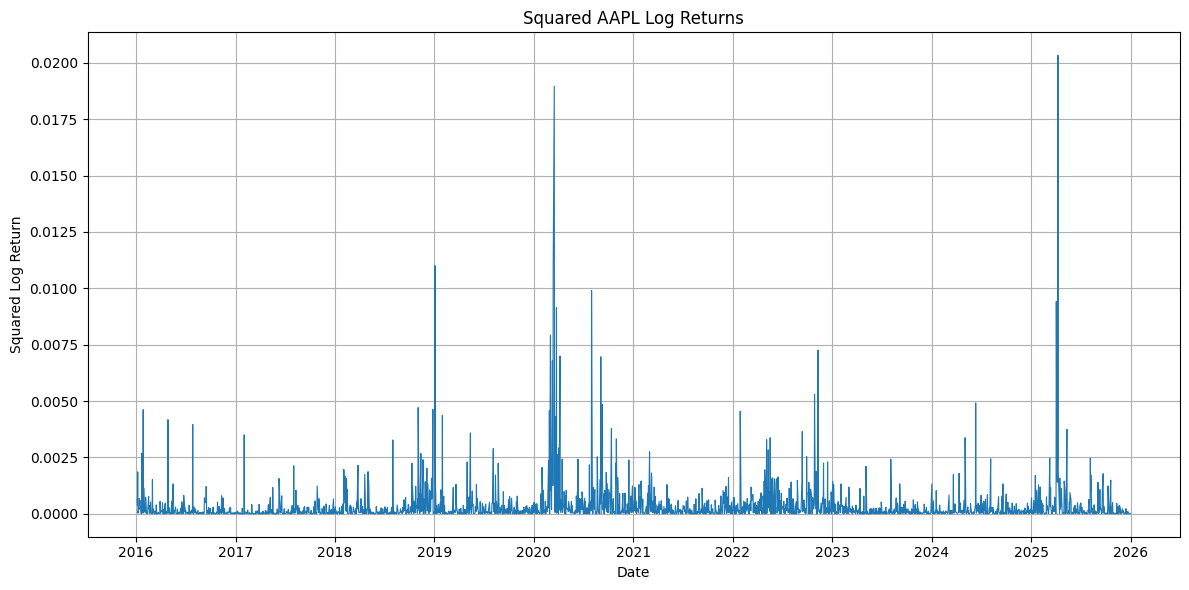

In [20]:
fig, ax = plt.subplots()

ax.plot(df.index, df["Log_Return"] ** 2, linewidth=0.8)
ax.set_title("Squared AAPL Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Squared Log Return")

plt.tight_layout()
plt.savefig(fig_dir / "aapl_squared_returns.png", dpi=300, bbox_inches="tight")
plt.show()

The presence of volatility clustering suggests that the variance of returns changes over time rather than remaining constant. This behaviour motivates the use of volatility models, such as GARCH, in financial econometrics and supports the incorporation of stochastic volatility considerations in risk management and derivative pricing.

### Distribution Behavior

Financial returns often deviate from the normal distribution. Skewness, excess kurtosis, and the Jarque-Bera test are used to evaluate whether AAPL log returns show asymmetry and fat tails.

In [21]:
print("Skewness:", round(skew(df["Log_Return"]), 6))
print("Excess kurtosis:", round(kurtosis(df["Log_Return"], fisher=True), 6))
print("Jarque-Bera statistic:", round(jb_stat, 6))
print("Jarque-Bera p-value:", round(jb_pvalue, 6))

Skewness: -0.091839
Excess kurtosis: 6.697035
Jarque-Bera statistic: 4699.73011
Jarque-Bera p-value: 0.0


Since the excess kurtosis is positive, the return distribution has heavier tails than a normal distribution. A low Jarque-Bera p-value indicates that normality is rejected, which is common for financial return data.

### Summary Output for Later Monte Carlo Simulation

The following summary table contains the main values needed for the later simulation and option pricing sections. These include the last observed price, daily mean return, daily volatility, annualized mean return, and annualized volatility.

In [22]:
partner_summary = pd.DataFrame({
    "Item": [
        "Ticker",
        "Sample period",
        "Frequency",
        "Price variable",
        "Number of observations",
        "Last AAPL price",
        "Daily mean log return",
        "Daily volatility",
        "Annualized mean return",
        "Annualized volatility"
    ],
    "Value": [
        ticker,
        "2016-01-01 to 2025-12-31",
        "Daily",
        "Adjusted Close",
        len(df),
        df["Price"].iloc[-1],
        daily_mean,
        daily_vol,
        annualized_mean,
        annualized_vol
    ]
})

display(partner_summary)

partner_summary.to_csv(table_dir / "aapl_summary_for_partner.csv", index=False, encoding="utf-8-sig")

,Item,Value
0,Ticker,AAPL
1,Sample period,2016-01-01 to 2025-12-31
2,Frequency,Daily
3,Price variable,Adjusted Close
4,Number of observations,2513
5,Last AAPL price,271.355835
6,Daily mean log return,0.00097
7,Daily volatility,0.018281
8,Annualized mean return,0.244436
9,Annualized volatility,0.290207


In [23]:
#Output Verfication
files_to_check = [
    data_dir / "aapl_raw.csv",
    data_dir / "aapl_clean.csv",
    table_dir / "aapl_descriptive_statistics.csv",
    table_dir / "aapl_adf_results.csv",
    table_dir / "aapl_summary_for_partner.csv",
    fig_dir / "aapl_price.png",
    fig_dir / "aapl_log_returns.png",
    fig_dir / "aapl_return_histogram.png",
    fig_dir / "aapl_rolling_mean.png",
    fig_dir / "aapl_rolling_volatility.png",
    fig_dir / "aapl_acf_returns.png",
    fig_dir / "aapl_squared_returns.png"
]

for file in files_to_check:
    print(file, "exists:", file.exists())

data\aapl_raw.csv exists: True
data\aapl_clean.csv exists: True
outputs\tables\aapl_descriptive_statistics.csv exists: True
outputs\tables\aapl_adf_results.csv exists: True
outputs\tables\aapl_summary_for_partner.csv exists: True
outputs\figures\aapl_price.png exists: True
outputs\figures\aapl_log_returns.png exists: True
outputs\figures\aapl_return_histogram.png exists: True
outputs\figures\aapl_rolling_mean.png exists: True
outputs\figures\aapl_rolling_volatility.png exists: True
outputs\figures\aapl_acf_returns.png exists: True
outputs\figures\aapl_squared_returns.png exists: True


# 6. Time Series Modeling (ARIMA)

The previous analysis showed that AAPL log returns are stationary according to the Augmented Dickey-Fuller (ADF) test.

Since stationarity is a key requirement for ARIMA modeling, we now investigate whether there is any short-term linear dependence in the return series.

The objective of this section is not to build a highly accurate forecasting model, but rather to examine whether past returns contain information that may help explain future returns.

Autoregressive Integrated Moving Average (ARIMA) models are widely used for time series analysis and forecasting.

The general ARIMA(p,d,q) model consists of:

- p = autoregressive order
- d = differencing order
- q = moving average order

Since the return series is already stationary, the differencing parameter is set to:

$$ d = 0 $$

The analysis proceeds as follows:

1. Examine autocorrelation patterns using ACF and PACF plots.
2. Compare several low-order ARIMA models.
3. Fit an ARIMA model to the return series.
4. Analyze residuals.
5. Test whether residuals behave as white noise.

This helps determine whether linear time-series models adequately describe the dynamics of AAPL returns.

## 6.1 Model Identification using ACF and PACF
Before fitting an ARIMA model, it is useful to examine the autocorrelation structure of the return series.

### Autocorrelation Function (ACF)
The ACF measures the correlation between observations separated by different time lags.

### Partial Autocorrelation Function (PACF)
The PACF measures the direct correlation between observations after controlling for intermediate lags.
Financial return series typically exhibit weak autocorrelation. Therefore, only relatively simple ARIMA specifications are considered.

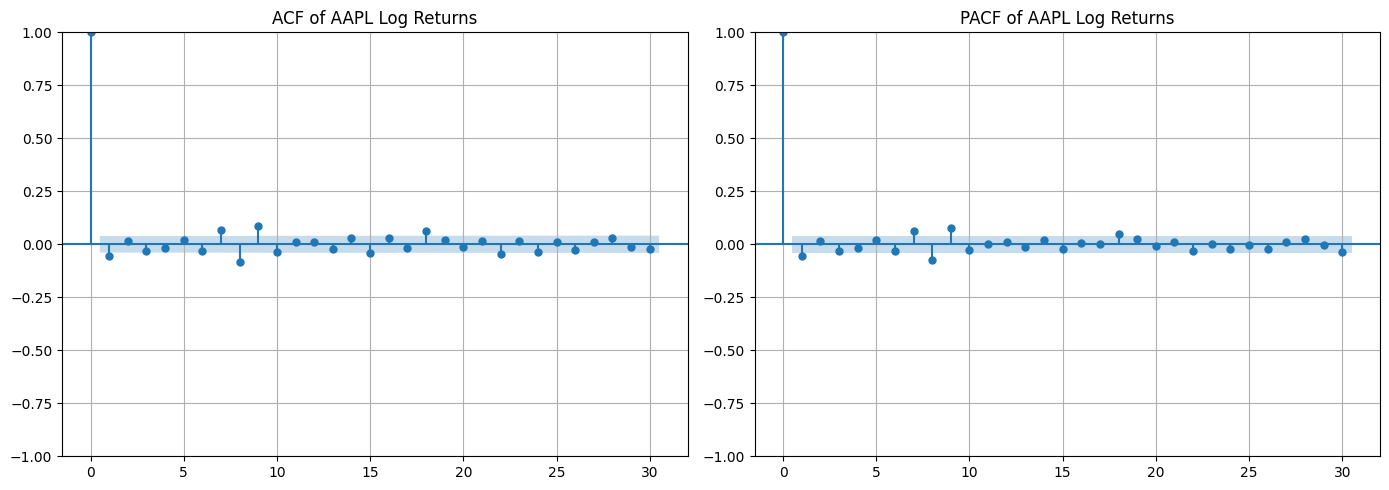

Interpretation:
- Returns exhibit weak autocorrelation
- No strong autoregressive pattern is observed
- A low-order ARIMA model is sufficient


In [24]:

returns = df["Log_Return"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF
plot_acf(
    returns,
    lags=30,
    ax=axes[0],
    alpha=0.05
)

axes[0].set_title("ACF of AAPL Log Returns")

# PACF
plot_pacf(
    returns,
    lags=30,
    ax=axes[1],
    method="ywm",
    alpha=0.05
)

axes[1].set_title("PACF of AAPL Log Returns")

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Returns exhibit weak autocorrelation")
print("- No strong autoregressive pattern is observed")
print("- A low-order ARIMA model is sufficient")

## 6.2 ARIMA Model Selection

Several low-order ARIMA models are compared using the Akaike Information Criterion (AIC).

The AIC balances model fit and model complexity.

Lower AIC values indicate a better trade-off between explanatory power and simplicity.

The candidate models are:

- ARIMA(1,0,0)
- ARIMA(0,0,1)
- ARIMA(1,0,1)

The model with the lowest AIC is selected for further analysis.

In [25]:
candidate_models = [
    (1,0,0),
    (0,0,1),
    (1,0,1)
]

results = []

for order in candidate_models:

    model = ARIMA(
        returns,
        order=order
    )

    fitted = model.fit()

    results.append({
        "Model": f"ARIMA{order}",
        "AIC": fitted.aic
    })

aic_df = pd.DataFrame(results)

aic_df = aic_df.sort_values(
    by="AIC"
)

print("AIC Comparison")
print("-"*40)

display(aic_df)

AIC Comparison
----------------------------------------


,Model,AIC
0,"ARIMA(1, 0, 0)",-12984.699621
1,"ARIMA(0, 0, 1)",-12984.473225
2,"ARIMA(1, 0, 1)",-12983.619679


## 6.3 Fitting the ARIMA Model
Based on the AIC comparison, a low-order ARIMA model is fitted to the return series.
For simplicity and interpretability, an ARIMA(1,0,0) specification is used.

The model can be written as:

$$ X_t = c + \phi X_{t-1} + \theta \varepsilon_{t-1} + \varepsilon_t $$

where:
- $X_t$ = log return
- $c$ = constant
- $\phi$ = autoregressive coefficient
- $\theta$ = moving average coefficient
- $\varepsilon_t$ = random error

The significance of the estimated parameters helps determine whether return dynamics exhibit meaningful linear dependence.

In [26]:
arima_model = ARIMA(
    returns,
    order=(1,0,0)
)

arima_result = arima_model.fit()

print("="*70)
print("ARIMA(1,0,0) MODEL SUMMARY")
print("="*70)

print(arima_result.summary())

ARIMA(1,0,0) MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                 2513
Model:                 ARIMA(1, 0, 0)   Log Likelihood                6495.350
Date:                Mon, 29 Jun 2026   AIC                         -12984.700
Time:                        23:13:27   BIC                         -12967.212
Sample:                             0   HQIC                        -12978.352
                               - 2513                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.000      2.786      0.005       0.000       0.002
ar.L1         -0.0559      0.012     -4.723      0.000      -0.079      -0.033
sigma2         0.0003   4

## 6.4 Residual Diagnostics

After fitting the ARIMA model, the residuals are examined.
If the model adequately captures the linear dependence in the data, the residuals should behave approximately as white noise.
The following diagnostics are considered:

- Residual time series
- Residual histogram
- Residual autocorrelation
- Q-Q plot

These diagnostics help assess model adequacy.

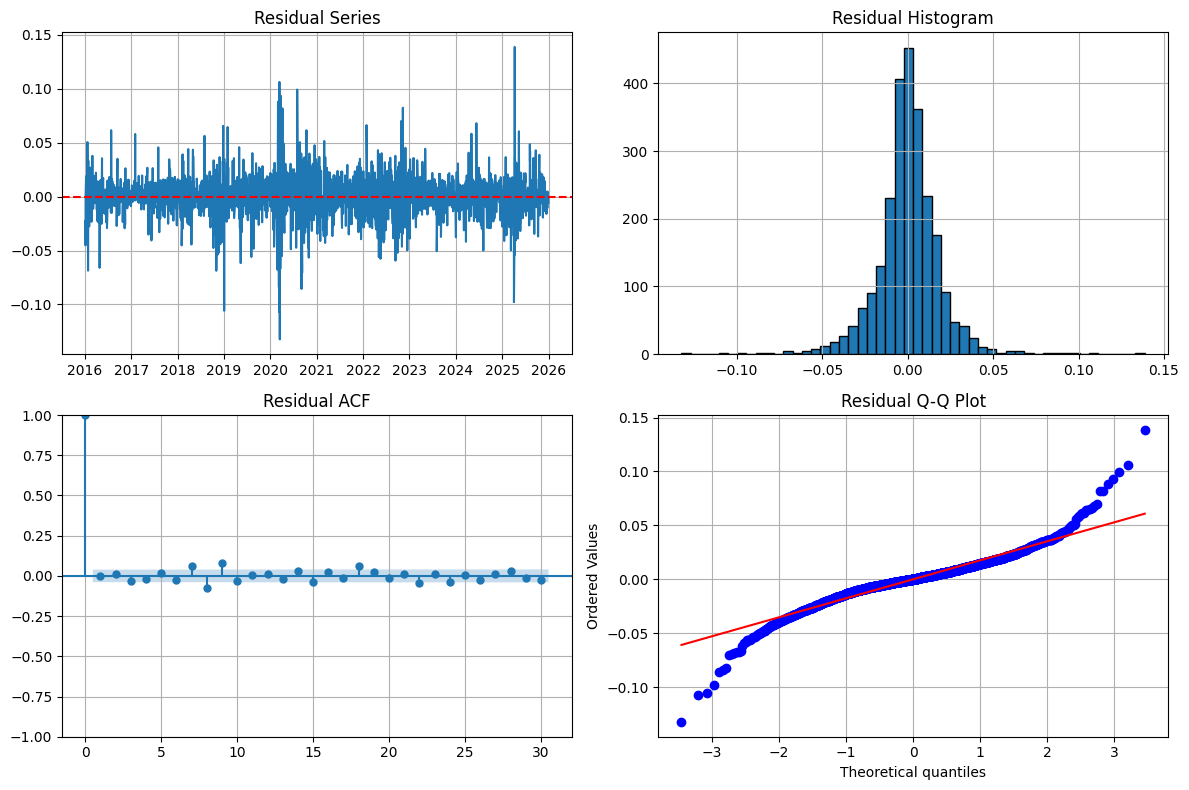

In [27]:
residuals = arima_result.resid

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

# Residual series
axes[0,0].plot(
    residuals.index,
    residuals
)

axes[0,0].axhline(
    0,
    color="red",
    linestyle="--"
)

axes[0,0].set_title(
    "Residual Series"
)

# Histogram
axes[0,1].hist(
    residuals,
    bins=50,
    edgecolor="black"
)

axes[0,1].set_title(
    "Residual Histogram"
)

# Residual ACF
plot_acf(
    residuals.dropna(),
    lags=30,
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Residual ACF"
)

# QQ plot
stats.probplot(
    residuals,
    dist="norm",
    plot=axes[1,1]
)

axes[1,1].set_title(
    "Residual Q-Q Plot"
)

plt.tight_layout()
plt.show()

In [28]:
print("Residual Statistics")
print("-"*40)

print(f"Mean      : {residuals.mean():.6f}")
print(f"Std Dev   : {residuals.std():.6f}")
print(f"Skewness  : {residuals.skew():.4f}")
print(f"Kurtosis  : {residuals.kurtosis():.4f}") #shows the "tailedness" of the distribution

Residual Statistics
----------------------------------------
Mean      : 0.000000
Std Dev   : 0.018253
Skewness  : -0.1258
Kurtosis  : 6.3374


## 6.5 Ljung-Box Test

The Ljung-Box test is used to determine whether significant autocorrelation remains in the residuals.

### Hypotheses
**H₀:** Residuals are independently distributed (white noise)
**H₁:** Residual autocorrelation remains

A p-value greater than 0.05 indicates that the residuals behave approximately as white noise.

In [29]:
ljung_box = acorr_ljungbox(
    residuals.dropna(),
    lags=[5,10,15,20],
    return_df=True
)

print("="*60)
print("LJUNG-BOX TEST RESULTS")
print("="*60)

display(ljung_box)

all_pvalues = ljung_box["lb_pvalue"]

if (all_pvalues > 0.05).all():

    print("\nConclusion:")
    print("Residuals behave approximately as white noise.")
    print("The ARIMA model adequately captures linear dependence.")

else:

    print("\nConclusion:")
    print("Residual autocorrelation remains.")
    print("The ARIMA model may be misspecified.")

LJUNG-BOX TEST RESULTS


,lb_stat,lb_pvalue
5,4.371536,4.972531e-01
10,48.081893,5.996615e-07
15,55.199170,1.653354e-06
20,68.338205,3.393775e-07



Conclusion:
Residual autocorrelation remains.
The ARIMA model may be misspecified.


# 7. Geometric Brownian Motion (GBM) Framework

Having analyzed the historical characteristics of AAPL returns and examined their time-series properties using ARIMA models, the next step is to develop a stochastic model for future stock price movements.
In computational finance, one of the most widely used models for asset price simulation is the **Geometric Brownian Motion (GBM)** model.

GBM combines:

- A deterministic growth component (drift)
- A random component (volatility)

while ensuring that simulated stock prices remain strictly positive.
The model serves as the foundation of the Black-Scholes option pricing framework and many Monte Carlo valuation methods.
The objective of this section is to estimate the GBM parameters from historical AAPL returns and establish the stochastic framework used later for Monte Carlo simulation and option pricing.

### References

Hull, J. C. (2018). *Options, Futures, and Other Derivatives* (10th ed.). Pearson.

Black, F., & Scholes, M. (1973). *The Pricing of Options and Corporate Liabilities*. Journal of Political Economy, 81(3), 637–654.

## 7.1 Geometric Brownian Motion Model
Under the Geometric Brownian Motion assumption, stock prices evolve according to the Stochastic Differential Equation (SDE)

$$dS_t = \mu S_t dt + \sigma S_t dW_t$$


where:

- $S_t$ = stock price at time $t$
- $\mu$ = drift parameter
- $\sigma$ = volatility parameter
- $W_t$ = Brownian motion (Wiener process)

The first term represents the expected growth of the stock price, while the second term captures random market fluctuations.
Applying Itô's Lemma gives the closed-form solution

$$S_t = S_0 \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right]$$

An important implication of this result is that stock prices are lognormally distributed and therefore remain positive throughout the simulation period.

## 7.2 Discrete-Time Simulation Form

For Monte Carlo simulation, the continuous-time GBM model must be converted into a discrete-time form.
The discrete GBM equation is given by

$$S_{t+\Delta t} = S_t \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t} Z_t\right]$$

where:
- $Z_t \sim N(0,1)$
- $\Delta t$ is the time step
- $Z_t$ represents a random shock drawn from a standard normal distribution
For this project, daily trading intervals are used:

$$ \Delta t = \frac{1}{252} $$
assuming approximately 252 trading days per year.
This equation forms the basis of the Monte Carlo simulation developed in the next section.

## 7.3 Parameter Estimation

The GBM model requires estimates of three key quantities:
- Initial stock price ($S_0$)
- Drift ($\mu$)
- Volatility ($\sigma$)

The initial stock price is taken as the most recent observed AAPL closing price.
The drift and volatility parameters are estimated from the historical log return series calculated earlier.
To make the parameters consistent with annual option-pricing conventions, the daily return statistics are annualized using 252 trading days per year.

In [30]:
# Historical log returns
log_returns = df["Log_Return"].dropna()

# Annualized drift
mu_annual = log_returns.mean() * 252

# Annualized volatility
sigma_annual = log_returns.std() * np.sqrt(252)

# Current stock price
S0 = df["Price"].iloc[-1]

# Risk-free rate
r = 0.045

# Simulation horizon
T = 1.0

# Daily time step
dt = 1 / 252

print("="*60)
print("GEOMETRIC BROWNIAN MOTION PARAMETERS")
print("="*60)

print(f"Current Stock Price (S0): ${S0:.2f}")
print(f"Annual Drift (μ):        {mu_annual:.4f}")
print(f"Annual Drift (%):        {mu_annual*100:.2f}%")
print(f"Annual Volatility (σ):   {sigma_annual:.4f}")
print(f"Annual Volatility (%):   {sigma_annual*100:.2f}%")
print(f"Risk-Free Rate (r):      {r:.2%}")
print(f"Time Horizon (T):        {T:.1f} year")
print(f"Daily Time Step (dt):    {dt:.6f}")

print("="*60)

# Store parameters for later use

gbm_params = {
    "S0": S0,
    "mu": mu_annual,
    "sigma": sigma_annual,
    "r": r,
    "T": T,
    "dt": dt
}

gbm_params

GEOMETRIC BROWNIAN MOTION PARAMETERS
Current Stock Price (S0): $271.36
Annual Drift (μ):        0.2444
Annual Drift (%):        24.44%
Annual Volatility (σ):   0.2902
Annual Volatility (%):   29.02%
Risk-Free Rate (r):      4.50%
Time Horizon (T):        1.0 year
Daily Time Step (dt):    0.003968


{'S0': np.float64(271.3558349609375),
 'mu': np.float64(0.24443615234128102),
 'sigma': np.float64(0.29020683435633393),
 'r': 0.045,
 'T': 1.0,
 'dt': 0.003968253968253968}

## 7.4 Historical Risk and Return Characteristics

Before running Monte Carlo simulations, it is useful to summarize the historical risk and return characteristics of AAPL.
The average annual return provides an estimate of expected growth, while volatility measures the uncertainty associated with future price movements.
These quantities serve as the primary inputs into the GBM framework.

In [31]:
risk_return = pd.DataFrame({
    "Metric": [
        "Annual Return",
        "Annual Volatility"
    ],
    "Value": [
        mu_annual,
        sigma_annual
    ]
})

risk_return["Value"] = (
    risk_return["Value"] * 100
).round(2)

risk_return.rename(
    columns={"Value": "Percentage (%)"},
    inplace=True
)

risk_return

,Metric,Percentage (%)
0,Annual Return,24.44
1,Annual Volatility,29.02


<a id="8"></a>

# 8. Monte Carlo Simulation

Monte Carlo simulation is a numerical technique that uses repeated random sampling to estimate the distribution of future outcomes.

In finance, Monte Carlo methods are widely used to model future asset prices, assess investment risk, and value financial derivatives. Rather than producing a single forecast, Monte Carlo simulation generates thousands of possible future scenarios, allowing analysts to evaluate both expected returns and uncertainty.

Using the Geometric Brownian Motion (GBM) framework established in Section 7, this section simulates 10,000 possible future price paths for AAPL over a one-year horizon.

The simulation is based on the discrete-time GBM equation:

$$S_{t+\Delta t} = S_t \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t} Z_t\right]$$

where:

- $S_t$ = stock price at time $t$
- $\mu$ = annual drift
- $\sigma$ = annual volatility
- $\Delta t$ = time step
- $Z_t \sim N(0,1)$

The objective is to generate a distribution of future stock prices that preserves the historical risk-return characteristics observed in the AAPL data.
The simulated terminal prices will later be used to estimate European call and put option values via Monte Carlo methods.

Reference:

Hull, J. C. (2018). *Options, Futures, and Other Derivatives* (10th ed.). Pearson.

## 8.1 Simulation Setup

The Monte Carlo simulation uses the parameters estimated from the historical AAPL return series.

The simulation assumptions are summarized below:

| Parameter | Symbol | Value |
|------------|---------|---------|
| Initial Price | $S_0$ | Latest AAPL Closing Price |
| Drift | $\mu$ | Historical Estimate |
| Volatility | $\sigma$ | Historical Estimate |
| Time Horizon | $T$ | 1 Year |
| Trading Days | $N$ | 252 |
| Simulations | $M$ | 10,000 |

A fixed random seed is used to ensure that results are reproducible.

In [32]:
# Reproducibility
np.random.seed(42)

# Simulation settings
n_sims = 10000
n_days = 252

# Retrieve GBM parameters
S0 = gbm_params["S0"]
mu = gbm_params["mu"]
sigma = gbm_params["sigma"]
dt = gbm_params["dt"]

print("="*60)
print("MONTE CARLO SIMULATION SETUP")
print("="*60)

print(f"Initial Price (S0): ${S0:.2f}")
print(f"Annual Drift (μ): {mu:.4f}")
print(f"Annual Volatility (σ): {sigma:.4f}")
print(f"Trading Days: {n_days}")
print(f"Number of Simulations: {n_sims:,}")

print("="*60)

MONTE CARLO SIMULATION SETUP
Initial Price (S0): $271.36
Annual Drift (μ): 0.2444
Annual Volatility (σ): 0.2902
Trading Days: 252
Number of Simulations: 10,000


## 8.2 Simulating AAPL Price Paths

Using the estimated GBM parameters, 10,000 future stock price paths are generated.

Each path represents one possible future evolution of the AAPL stock price over the next year.

To improve computational efficiency, the simulation is performed using vectorized NumPy operations.

In [33]:
# Matrix to store simulated prices
paths = np.zeros((n_days + 1, n_sims))

# Initial prices
paths[0] = S0

# Random shocks
random_shocks = np.random.standard_normal(
    (n_days, n_sims)
)

# Simulate paths
for t in range(1, n_days + 1):

    paths[t] = (
        paths[t - 1]
        * np.exp(
            (mu - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * random_shocks[t - 1]
        )
    )

print("Monte Carlo simulation completed.")
print(f"Total simulated paths: {n_sims:,}")

# Terminal prices
terminal_prices = paths[-1]
print(f"Mean terminal price: ${terminal_prices.mean():.2f}")

Monte Carlo simulation completed.
Total simulated paths: 10,000
Mean terminal price: $345.67


## 8.3 Visualizing Simulated Price Paths

The figure below shows the first 100 simulated AAPL price paths.

Although all simulations begin from the same initial price, they gradually diverge due to the accumulation of random shocks.

The widening spread illustrates the increasing uncertainty associated with longer forecasting horizons.

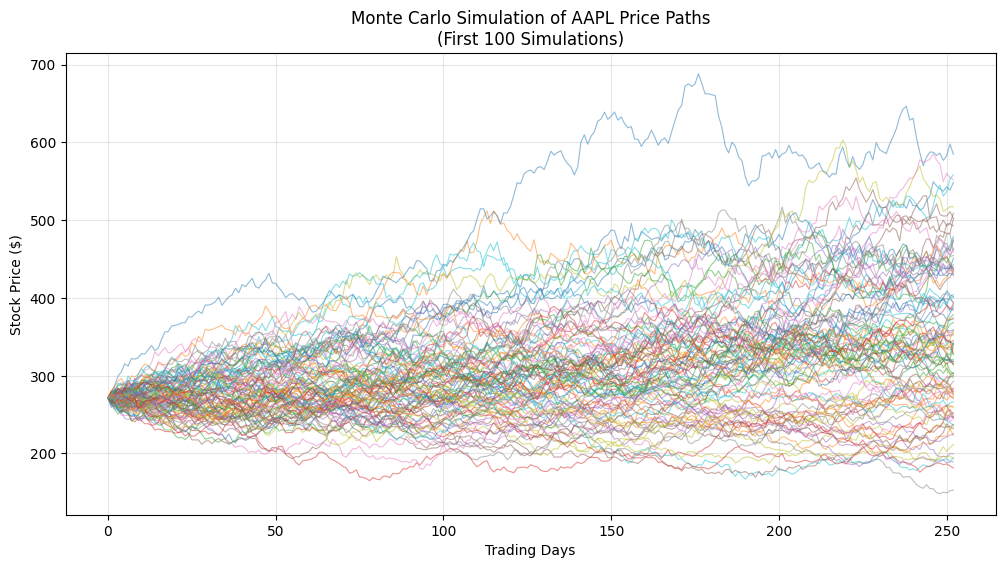

In [34]:
plt.figure(figsize=(12,6))

for i in range(100):
    plt.plot(
        paths[:, i],
        linewidth=0.8,
        alpha=0.5
    )

plt.title(
    "Monte Carlo Simulation of AAPL Price Paths\n(First 100 Simulations)"
)

plt.xlabel("Trading Days")
plt.ylabel("Stock Price ($)")
plt.grid(True, alpha=0.3)

plt.show()

## 8.4 Terminal Price Distribution

The most important output of a Monte Carlo simulation is the distribution of terminal stock prices.
The histogram below displays the simulated AAPL prices after one year.
Under the GBM assumption, terminal prices should follow an approximately lognormal distribution, producing a positively skewed shape with a long right tail.

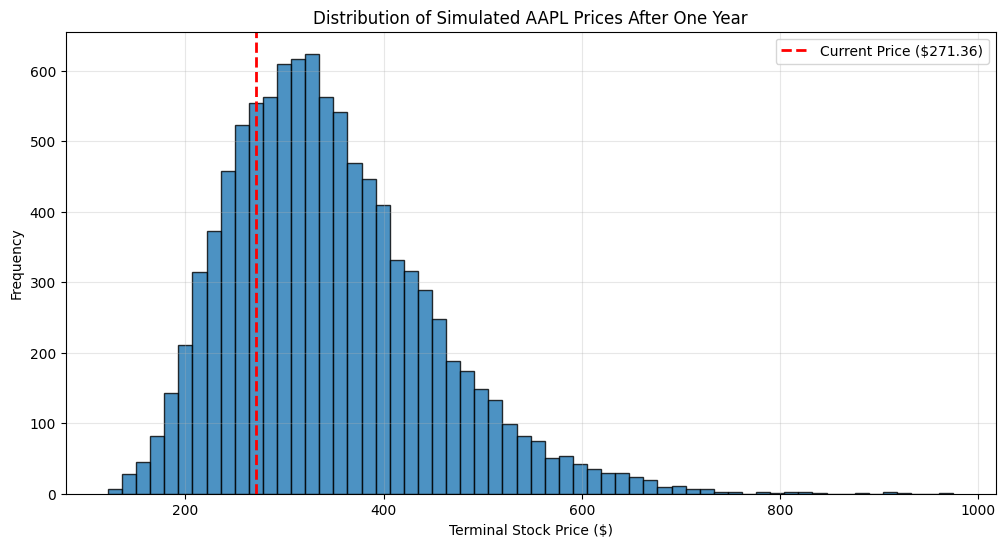

In [35]:
plt.figure(figsize=(12,6))

plt.hist(
    terminal_prices,
    bins=60,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    S0,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Current Price (${S0:.2f})"
)

plt.title("Distribution of Simulated AAPL Prices After One Year")
plt.xlabel("Terminal Stock Price ($)")
plt.ylabel("Frequency")
plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

## 8.5 Simulation Summary Statistics

The simulation results can be summarized using descriptive statistics.
These statistics provide insight into:

- Expected future price levels
- Dispersion of outcomes
- Downside risk
- Upside potential

Percentiles are particularly useful because they describe the range within which future prices are likely to occur.

In [36]:
simulation_summary = pd.DataFrame({

    "Statistic": [
        "Initial Price",
        "Mean Terminal Price",
        "Median Terminal Price",
        "Standard Deviation",
        "Minimum",
        "5th Percentile",
        "25th Percentile",
        "75th Percentile",
        "95th Percentile",
        "Maximum"
    ],

    "Value": [
        S0,
        terminal_prices.mean(),
        np.median(terminal_prices),
        terminal_prices.std(),
        terminal_prices.min(),
        np.percentile(terminal_prices, 5),
        np.percentile(terminal_prices, 25),
        np.percentile(terminal_prices, 75),
        np.percentile(terminal_prices, 95),
        terminal_prices.max()
    ]
})

simulation_summary["Value"] = (
    simulation_summary["Value"]
    .round(2)
)

print(simulation_summary)

prob_gain = np.mean(terminal_prices > S0)
prob_loss = np.mean(terminal_prices < S0)

print("="*50)
print("PROBABILITY ANALYSIS")
print("="*50)

print(f"Probability of Gain: {prob_gain:.2%}")
print(f"Probability of Loss: {prob_loss:.2%}")

print("="*50)

               Statistic   Value
0          Initial Price  271.36
1    Mean Terminal Price  345.67
2  Median Terminal Price  331.91
3     Standard Deviation  101.82
4                Minimum  121.73
5         5th Percentile  206.14
6        25th Percentile  272.69
7        75th Percentile  403.29
8        95th Percentile  532.89
9                Maximum  974.91
PROBABILITY ANALYSIS
Probability of Gain: 75.48%
Probability of Loss: 24.52%


## 8.6 Comparing Historical and Simulated Risk/Return

One objective of the project is to determine whether the Monte Carlo simulation reproduces the historical risk-return characteristics of AAPL.

To evaluate this, the annualized return and volatility implied by the simulated terminal prices are compared with the historical estimates used to calibrate the GBM model.

In [37]:
simulated_return = np.mean(
    np.log(terminal_prices / S0)
)

simulated_volatility = np.std(
    np.log(terminal_prices / S0)
)

comparison = pd.DataFrame({

    "Metric": [
        "Historical Drift",
        "Simulated Mean Return",
        "Historical Volatility",
        "Simulated Volatility"
    ],

    "Value": [
        mu,
        simulated_return,
        sigma,
        simulated_volatility
    ]
})

comparison["Value"] = (
    comparison["Value"] * 100
).round(2)

comparison.rename(
    columns={"Value": "Percentage (%)"},
    inplace=True
)

comparison

,Metric,Percentage (%)
0,Historical Drift,24.44
1,Simulated Mean Return,20.02
2,Historical Volatility,29.02
3,Simulated Volatility,28.96


<a id="9"></a>

# 9. European Option Pricing

The simulated stock prices generated in Section 8 can be used to estimate the value of European-style options.

A European option can only be exercised at maturity. Therefore, the option payoff depends solely on the stock price at expiration.

Under the risk-neutral valuation framework, the value of an option equals the discounted expected payoff under the risk-neutral probability measure.

For a European call option:

$$C = e^{-rT} \mathbb{E}\left[\max(S_T - K, 0)\right] $$

For a European put option:

$$P = e^{-rT} \mathbb{E}\left[\max(K - S_T, 0)\right]$$

where:

- $S_T$ = stock price at maturity
- $K$ = strike price
- $r$ = risk-free interest rate
- $T$ = time to maturity

The expectations are approximated using the simulated terminal stock prices generated in the Monte Carlo experiment.

This approach is particularly useful when analytical pricing formulas are unavailable or difficult to apply.

Reference:

Hull, J. C. (2018). *Options, Futures, and Other Derivatives* (10th ed.). Pearson.

## 9.1 Option Parameters

To illustrate the valuation procedure, an at-the-money (ATM) European option is considered.

An at-the-money option has a strike price equal to the current stock price.
The option maturity is assumed to be one year, matching the simulation horizon used in the Monte Carlo analysis.

In [38]:
# RISK-NEUTRAL MONTE CARLO SIMULATION FOR OPTION PRICING

# Unlike the stock-price forecasting simulation in Section 8,
# option pricing requires the use of the risk-free rate (r)
# rather than the historical drift (mu). Under the risk-neutral
# valuation framework, all assets are assumed to grow at the
# risk-free rate after adjusting for risk. This ensures that
# the expected discounted payoff is consistent with no-arbitrage
# pricing theory and comparable to the Black-Scholes model.
K = S0
r = gbm_params["r"]
T = gbm_params["T"]

paths_option = np.zeros((n_days + 1, n_sims))
paths_option[0] = S0

for t in range(1, n_days + 1):

    paths_option[t] = (
        paths_option[t - 1]
        * np.exp(
            (r - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * random_shocks[t - 1]
        )
    )
    

# Calculate option payoffs from terminal prices
terminal_option_prices = paths_option[-1]
call_payoffs = np.maximum(terminal_option_prices - K, 0)
put_payoffs = np.maximum(K - terminal_option_prices, 0)

# Calculate option prices (discounted expected payoffs)
call_price_mc = np.exp(-r * T) * np.mean(call_payoffs)
put_price_mc = np.exp(-r * T) * np.mean(put_payoffs)

print("="*50)
print("OPTION PARAMETERS")
print("="*50)

print(f"Current Stock Price (S0): ${S0:.2f}")
print(f"Strike Price (K):        ${K:.2f}")
print(f"Risk-Free Rate (r):      {r:.2%}")
print(f"Time to Maturity (T):    {T:.1f} year")
print(f"European Call Price: ${call_price_mc:.4f}")
print(f"European Put Price : ${put_price_mc:.4f}")

print("="*50)

OPTION PARAMETERS
Current Stock Price (S0): $271.36
Strike Price (K):        $271.36
Risk-Free Rate (r):      4.50%
Time to Maturity (T):    1.0 year
European Call Price: $36.4829
European Put Price : $25.1884


## 9.2 Monte Carlo Option Valuation

The terminal stock prices generated in Section 8 are used to calculate option payoffs.

For each simulation:

- Call payoff = max($S_T-K$, 0)
- Put payoff = max($K-S_T$, 0)

The average payoff across all simulations is then discounted back to present value using the risk-free interest rate.

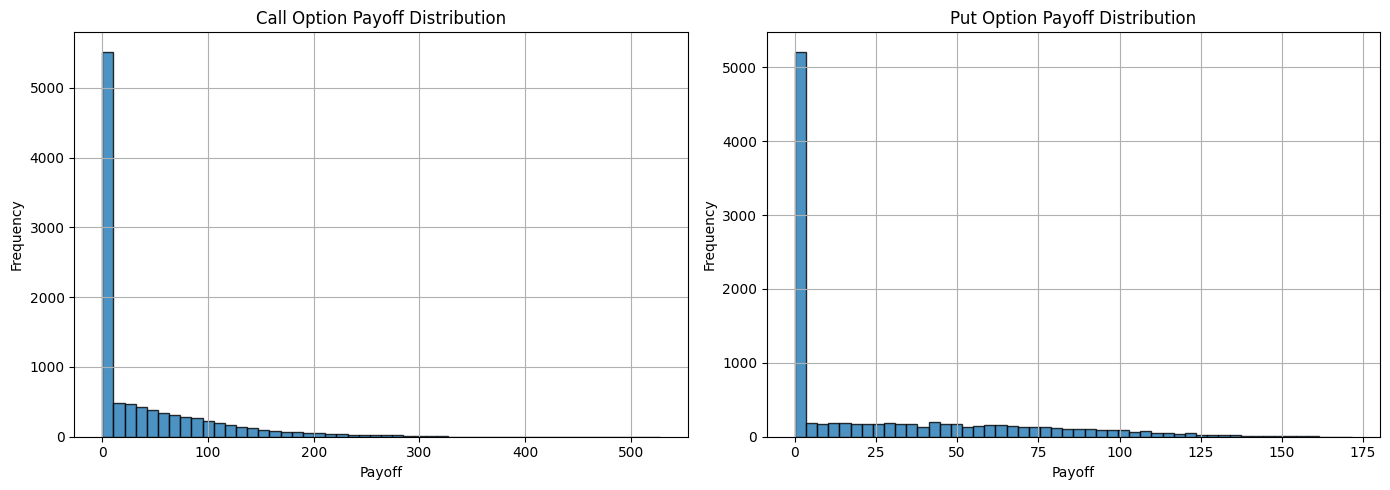

In [39]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

axes[0].hist(
    call_payoffs,
    bins=50,
    edgecolor="black",
    alpha=0.8
)

axes[0].set_title(
    "Call Option Payoff Distribution"
)

axes[0].set_xlabel("Payoff")
axes[0].set_ylabel("Frequency")

axes[1].hist(
    put_payoffs,
    bins=50,
    edgecolor="black",
    alpha=0.8
)

axes[1].set_title(
    "Put Option Payoff Distribution"
)

axes[1].set_xlabel("Payoff")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 9.4 Black-Scholes Validation

Because the Monte Carlo simulation assumes Geometric Brownian Motion, the resulting option prices can be compared with the Black-Scholes model.

Both methods are based on the same underlying assumptions. Therefore, when the number of simulations is sufficiently large, the Monte Carlo estimates should converge toward the Black-Scholes values.

This comparison serves as a useful validation check for the simulation framework.

In [40]:
from scipy.stats import norm

def black_scholes_call(S0, K, T, r, sigma):

    d1 = (
        np.log(S0/K)
        +
        (r + 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    d2 = d1 - sigma*np.sqrt(T)

    return (
        S0 * norm.cdf(d1)
        -
        K*np.exp(-r*T)*norm.cdf(d2)
    )


def black_scholes_put(S0, K, T, r, sigma):

    d1 = (
        np.log(S0/K)
        +
        (r + 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    d2 = d1 - sigma*np.sqrt(T)

    return (
        K*np.exp(-r*T)*norm.cdf(-d2)
        -
        S0*norm.cdf(-d1)
    )


bs_call = black_scholes_call(
    S0,
    K,
    T,
    r,
    sigma_annual
)

bs_put = black_scholes_put(
    S0,
    K,
    T,
    r,
    sigma_annual
)

print("="*50)
print("BLACK-SCHOLES PRICES")
print("="*50)

print(f"Call Price: ${bs_call:.4f}")
print(f"Put Price : ${bs_put:.4f}")

print("="*50)

BLACK-SCHOLES PRICES
Call Price: $36.9526
Put Price : $25.0123


## 9.5 Comparison of Pricing Methods

The table below compares the Monte Carlo estimates with the analytical Black-Scholes values.

Small differences are expected because Monte Carlo valuation relies on random sampling and therefore contains simulation error.

In [41]:
comparison = pd.DataFrame({

    "Method": [
        "Monte Carlo",
        "Black-Scholes"
    ],

    "Call Price": [
        call_price_mc,
        bs_call
    ],

    "Put Price": [
        put_price_mc,
        bs_put
    ]
})

comparison.round(4)

call_error = (
    abs(call_price_mc - bs_call)
    / bs_call
) * 100

put_error = (
    abs(put_price_mc - bs_put)
    / bs_put
) * 100

print(f"Call Pricing Error: {call_error:.2f}%")
print(f"Put Pricing Error : {put_error:.2f}%")

Call Pricing Error: 1.27%
Put Pricing Error : 0.70%


In [42]:
# OUTPUT CHECK: SECTIONS 6–9
files_to_check = [

    # SECTION 6 - ARIMA
    fig_dir / "aapl_acf_pacf.png",
    fig_dir / "aapl_arima_residual_diagnostics.png",

    # SECTION 8 - Monte Carlo Simulation
    fig_dir / "aapl_simulated_paths.png",
    fig_dir / "aapl_terminal_price_distribution.png",

    # SECTION 9 - Option Pricing
    fig_dir / "aapl_option_payoff_distribution.png",

]

for file in files_to_check:
    print(file, "exists:", file.exists())


# REPORT SUMMARY TABLE
best_arima_order = "ARIMA(1,0,0)"
fitted_arima_model = "ARIMA(1,0,0)"

report_summary = pd.DataFrame({

    "Metric": [
        "ARIMA Model Selection",
        "Fitted ARIMA Model",
        "AIC",
        "BIC",
        "Initial Price (S0)",
        "Drift (mu)",
        "Volatility (sigma)",
        "Risk-Free Rate (r)",
        "Strike Price (K)",
        "Maturity (T)",
        "Time Steps (N)",
        "Number of Simulations",
        "European Call Price",
        "European Put Price",
        "Black-Scholes Call Price",
        "Black-Scholes Put Price",
        "Call Pricing Difference",
        "Put Pricing Difference"
    ],

    "Value": [
        best_arima_order,
        fitted_arima_model,
        round(arima_result.aic, 3),
        round(arima_result.bic, 3),
        round(S0, 2),
        round(mu, 4),
        round(sigma, 4),
        r,
        round(K, 2),
        T,
        n_days,
        n_sims,
        round(call_price_mc, 4),
        round(put_price_mc, 4),
        round(bs_call, 4),
        round(bs_put, 4),
        round(call_error, 2),
        round(put_error, 2)
    ]
})

report_summary

outputs\figures\aapl_acf_pacf.png exists: True
outputs\figures\aapl_arima_residual_diagnostics.png exists: True
outputs\figures\aapl_simulated_paths.png exists: True
outputs\figures\aapl_terminal_price_distribution.png exists: True
outputs\figures\aapl_option_payoff_distribution.png exists: True


,Metric,Value
0,ARIMA Model Selection,"ARIMA(1,0,0)"
1,Fitted ARIMA Model,"ARIMA(1,0,0)"
2,AIC,-12984.7
3,BIC,-12967.212
4,Initial Price (S0),271.36
5,Drift (mu),0.2444
6,Volatility (sigma),0.2902
7,Risk-Free Rate (r),0.045
8,Strike Price (K),271.36
9,Maturity (T),1.0


## Conclusion

This project analyzed Apple Inc. (AAPL) stock returns using time-series modeling and Monte Carlo simulation techniques to forecast future price behavior and value European options. The stationarity analysis confirmed that the return series was suitable for ARIMA modeling, and model selection based on the Akaike Information Criterion identified ARIMA(1,0,0) as the most appropriate specification among the candidate models. The relatively low AIC and BIC values indicate that the model captures a significant portion of the short-term dependence structure in the returns while maintaining parsimony.

The estimated drift and volatility parameters obtained from the historical return series were subsequently incorporated into a Geometric Brownian Motion framework to simulate future stock price paths. The simulation results revealed substantial dispersion in possible future prices, reflecting the uncertainty inherent in equity markets. This demonstrates that while AAPL exhibits positive expected growth under the historical measure, substantial uncertainty remains around future stock prices, leading to a broad range of possible outcomes and highlighting the importance of risk assessment in option valuation.

Using risk-neutral Monte Carlo simulation, European call and put option values were estimated from the simulated terminal stock prices. The resulting call price of approximately $36.48 and put price of approximately $25.19 were found to be very close to the corresponding Black-Scholes values of $36.95 and $25.01. This close agreement validates the implementation of the simulation framework and confirms that the risk-neutral valuation approach produces option prices consistent with established analytical models. The results further demonstrate the significant influence of volatility and uncertainty in determining option values.

Furthermore, the small differences between the Monte Carlo and Black-Scholes prices indicate that the simulation employed a sufficient number of paths and appropriately captured the underlying stock price dynamics under the Geometric Brownian Motion assumption.

Overall, the findings show that combining ARIMA-based return analysis with Geometric Brownian Motion simulations provides a useful framework for understanding stock dynamics and option valuation. The approach enables both statistical characterization of historical returns and probabilistic assessment of future market outcomes, making it valuable for risk analysis and investment decision support.


## Limitations

Several limitations should be considered when interpreting the results. First, the ARIMA model relies exclusively on historical price information and therefore cannot capture unexpected market events, macroeconomic shocks, changes in company fundamentals, or shifts in investor sentiment that may significantly affect future returns.

Second, the Geometric Brownian Motion model assumes constant drift and volatility throughout the simulation horizon. In practice, financial markets often experience time-varying volatility, volatility clustering, and sudden price jumps, which may lead to deviations between simulated and actual market behavior.

Although the Monte Carlo and Black-Scholes prices were highly consistent in this study, both approaches rely on the same underlying Geometric Brownian Motion assumptions. Therefore, agreement between the two models does not necessarily imply that the estimated option prices will perfectly match observed market prices, particularly during periods of market stress or abnormal volatility.

Third, the option pricing framework assumes frictionless markets, continuous trading, and a constant risk-free interest rate. These assumptions simplify the valuation process but may not accurately reflect real-world market conditions.

Finally, the parameter estimates were derived from historical data over a specific sample period. Different estimation windows or market environments could produce different drift, volatility, and option pricing results. Consequently, the numerical values obtained in this study should be interpreted as model-based estimates rather than precise forecasts of future market performance.


## Code and Data Sources
The historical AAPL data are retrieved from Yahoo Finance using the Python package yfinance. The notebook uses daily adjusted closing prices for the period from 2016-01-01 to 2025-12-31. The implementation uses standard Python libraries including pandas, NumPy, matplotlib, scipy, statsmodels, and yfinance. The computational finance workflow follows standard approaches used in Python-based financial analysis, time series modeling, Monte Carlo simulation, and derivative pricing.


# References

Black, F., & Scholes, M. (1973). *The pricing of options and corporate liabilities*. Journal of Political Economy, 81(3), 637–654.

Dickey, D. A., & Fuller, W. A. (1979). *Distribution of the estimators for autoregressive time series with a unit root*. Journal of the American Statistical Association, 74(366), 427–431.

Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*. Springer.

Hull, J. C. (2018). *Options, Futures, and Other Derivatives* (10th ed.). Pearson.

Jarque, C. M., & Bera, A. K. (1987). *A test for normality of observations and regression residuals*. International Statistical Review, 55(2), 163–172.

Ljung, G. M., & Box, G. E. P. (1978). *On a measure of lack of fit in time series models*. Biometrika, 65(2), 297–303.

Tsay, R. S. (2010). *Analysis of Financial Time Series* (3rd ed.). Wiley.

Yahoo Finance. (2025). *Apple Inc. (AAPL) historical stock data*. Retrieved from https://finance.yahoo.com
